# 🏋️ Body Composition Classification Model

## 📝 Project Overview
This model provides a **comprehensive physiological analysis** by moving beyond the limitations of the traditional Body Mass Index (BMI). By integrating **Skeletal Muscle Mass (SMM)** and **Percent Body Fat (PBF)**, the engine categorizes individuals into 8 distinct physiological profiles with high precision.

---

## 📊 Classification Categories
The system identifies the following 8 profiles based on the interaction between weight, muscle, and fat:

| Category | Description |
| :--- | :--- |
| **🏆 Athletic** | High muscle mass with low/essential body fat levels. |
| **💪 Fit** | Optimal balance between healthy muscle mass and normal body fat. |
| **⚠️ Overweight** | Elevated BMI with body fat exceeding the healthy range. |
| **🔴 Obese** | High BMI accompanied by excessive body fat mass. |
| **📉 Underweight** | BMI below 18.5; requires nutritional intervention. |
| **🦴 Thin** | Low BMI but maintains a healthy muscle-to-fat ratio. |
| **👻 Skinny Fat** | Normal weight/BMI but characterized by high fat and low muscle mass. |
| **🧓 Sarcopenic** | Critical loss of muscle mass (Muscle Atrophy), often regardless of total weight. |

---

## 🛠️ Methodology & Scientific Standards
The classification logic is a **Rule-based System** built upon global clinical benchmarks:
*   **WHO:** Standardized BMI thresholds.
*   **ACSM:** PBF reference ranges adjusted for age and gender.
*   **DEXA Standards:** The "Gold Standard" for Lean Body Mass (LBM) and Sarcopenia detection.

---

## 🏗️ System Architecture
The model utilizes a **Hybrid Pipeline** to balance clinical rules with machine learning predictive power:
```mermaid
graph LR
    A[InBody Raw Data] --> B[Feature Engineering]
    B --> C[Rule Engine]
    B --> D[Random Forest - 500 Trees]
    C --> E[Hybrid Decision Engine]
    D --> E
    E --> F{Final Output}
    F --> G[Category]
    F --> H[Confidence Score]
    F --> I[Reasoning]

##  Import Libraries

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from openpyxl import load_workbook
from openpyxl.styles import PatternFill, Font, Alignment
from openpyxl.utils import get_column_letter
from datetime import datetime, timedelta
import matplotlib.image as mpimg
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 130, 'font.family': 'DejaVu Sans'})
print("✅ All libraries loaded successfully")

✅ All libraries loaded successfully


###  Medical Thresholds 
The model applies the following clinical thresholds to ensure evidence-based classification:

| Metric | Source | Male Range | Female Range |
| :--- | :--- | :--- | :--- |
| **BMI** | WHO | <18.5 (Under) / 25-30 (Over) / ≥30 (Obese) | *Same as Male* |
| **Body Fat %** | ACSM | Athletic: $\leq 13\%$ / Fit: $\leq 22\%$ | Athletic: $\leq 22\%$ / Fit: $\leq 30\%$ |
| **FFMI** | Kouri et al. | Athletic: $\geq 19.5$ / Sarco: $< 16$ | Athletic: $\geq 16$ / Sarco: $< 12.5$ |
| **SMM%** | InBody/DEXA | High: $\geq 44\%$ / Low: $< 32\%$ | High: $\geq 36\%$ / Low: $< 27\%$ |

> **Technical Note:** FFMI (Fat-Free Mass Index) is calculated as:  
> $FFMI = \frac{Lean\ Mass\ (kg)}{Height^2\ (m)}$  
> It is used as a primary indicator to distinguish between athletic profiles and muscle atrophy (Sarcopenia).

In [11]:
THRESHOLDS = {
    'male': {
        # Body Fat % (ACSM standards)
        'pbf_athletic_max':   13,    # ≤13%  → athletic fat zone
        'pbf_fit_max':        22,    # ≤22%  → fit zone
        'pbf_overweight_max': 30,    # >30%  → obese zone (with high BMI)
        # FFMI — Fat-Free Mass Index  (lean_kg / height_m²)
        'ffmi_athletic_min':  19.5,  # ≥19.5 → high muscle mass
        'ffmi_fit_min':       17.0,  # ≥17.0 → adequate muscle
        'ffmi_sarco_max':     16.0,  # <16.0 → muscle deficiency
        # SMM% — Skeletal Muscle as % of bodyweight
        'smm_pct_high':       44,    # ≥44%  → high muscle
        'smm_pct_normal_min': 38,    # ≥38%  → normal muscle
        'smm_pct_low':        32,    # <32%  → low muscle
        # BMI (WHO)
        'bmi_underweight':    18.5,
        'bmi_normal_max':     25.0,
        'bmi_overweight_max': 30.0,
    },
    'female': {
        'pbf_athletic_max':   22,
        'pbf_fit_max':        30,
        'pbf_overweight_max': 38,
        'ffmi_athletic_min':  16.0,
        'ffmi_fit_min':       13.5,
        'ffmi_sarco_max':     12.5,
        'smm_pct_high':       36,
        'smm_pct_normal_min': 31,
        'smm_pct_low':        27,
        'bmi_underweight':    18.5,
        'bmi_normal_max':     25.0,
        'bmi_overweight_max': 30.0,
    }
}

FEATURES = [
    'height', 'age', 'gender_bin', 'weight', 'smm', 'body_fat_mass',
    'water', 'protein', 'minerals', 'bmi', 'pbf',
    'smm_pct', 'lean_mass', 'ffmi', 'muscle_to_fat'
]

EMOJI = {
    'Athletic':'🏆','Fit':'💪','Overweight':'⚠️','Obese':'🔴',
    'Underweight':'📉','Thin':'🦴','Skinny Fat':'👻','Sarcopenic':'🧓'
}
COLOR_MAP = {
    'Athletic':'#28a745','Fit':'#007bff','Overweight':'#ffc107',
    'Obese':'#dc3545','Underweight':'#fd7e14','Thin':'#6c757d',
    'Skinny Fat':'#e83e8c','Sarcopenic':'#6610f2'
}

print("✅ Thresholds ready | Male & Female profiles configured")



✅ Thresholds ready | Male & Female profiles configured


##  Feature Engineering

In [21]:

# InBody biological constants (calibrated from real InBody data)
WATER_RATIO    = 0.733   # water    / lean_mass
PROTEIN_RATIO  = 0.198   # protein  / lean_mass
MINERALS_RATIO = 0.069   # minerals / lean_mass
SMM_LEAN_RATIO = 0.554   # smm      / lean_mass

def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Derive physiological metrics from raw InBody measurements.

    Added columns:
    ──────────────
    gender_bin    : 1=male  0=female
    smm_pct       : SMM kg / weight kg × 100   [ref ♂38-54% ♀28-39%]
    lean_mass     : weight × (1 - pbf/100)
    ffmi          : lean_mass / height_m²       [ref ♂17-22 ♀14-17]
    muscle_to_fat : smm / body_fat_mass         [higher = better composition]
    """
    d = df.copy()
    d['gender']        = d['gender'].astype(str).str.strip().str.lower()
    d['gender_bin']    = (d['gender'] == 'male').astype(int)
    d['smm_pct']       = (d['smm'] / d['weight']) * 100
    d['lean_mass']     = d['weight'] * (1 - d['pbf'] / 100)
    d['ffmi']          = d['lean_mass'] / (d['height'] / 100) ** 2
    d['muscle_to_fat'] = d['smm'] / d['body_fat_mass'].replace(0, np.nan)
    return d

print("✅ engineer_features() defined")
print("   Derived metrics: gender_bin | smm_pct | lean_mass | ffmi | muscle_to_fat")


✅ engineer_features() defined
   Derived metrics: gender_bin | smm_pct | lean_mass | ffmi | muscle_to_fat


##  Rule Engine — Zero-Error Deterministic Classifier

The Classification Engine follows a **Priority Cascade** (Sequential Logic). The system evaluates the body composition through a series of filters; the first profile that matches the criteria is assigned to the individual.

### 🏆 Priority Hierarchy (Highest → Lowest)

| Order | Profile | Logical Condition (Criteria) |
| :--- | :--- | :--- |
| **1** | **🔴 Obese** | $BMI \geq 30$ **AND** $PBF > Threshold$ |
| **2** | **🏆 Athletic** | **2 of 3 needed:** (Low Fat, High FFMI, High SMM%) |
| **3** | **💪 Fit** | **3 of 4 needed:** (Normal BMI, Good Muscle, Optimal Fat, High FFMI) |
| **4** | **⚠️ Overweight** | $BMI$ between $25.0 - 30.0$ |
| **5** | **🧓 Sarcopenic** | Low $FFMI$ **AND** Low $SMM\%$ (Indicates Muscle Atrophy) |
| **6** | **👻 Skinny Fat** | Normal $BMI$ **+** High $PBF$ **+** Low $SMM\%$ |
| **7** | **📉 Underweight** | $BMI < 18.5$ **+** Low $PBF$ **+** Low Muscle Mass |
| **8** | **🦴 Thin** | $BMI < 18.5$ **+** Acceptable $PBF$ (Naturally Lean) |

---

### 🧠 Logic Execution Flow
The "First Match Wins" strategy ensures that critical clinical conditions (like Obesity or Sarcopenia) are caught before general categories. 
```mermaid
graph TD
    Start[Input Features] --> C1{BMI >= 30 & Fat High?}
    C1 -- Yes --> Obese((🔴 Obese))
    C1 -- No --> C2{High Muscle & Low Fat?}
    C2 -- Yes --> Athletic((🏆 Athletic))
    C2 -- No --> C3{Balanced Metrics?}
    C3 -- Yes --> Fit((💪 Fit))
    C3 -- No --> C4{BMI 25-30?}
    C4 -- Yes --> Overweight((⚠️ Overweight))
    C4 -- No --> Others[Continue to Lower Priorities...]

In [24]:
def rule_classify(row: pd.Series, thresholds: dict = THRESHOLDS) -> tuple:
    """
    Deterministic body composition classifier.

    Parameters
    ----------
    row : pd.Series with columns: gender, bmi, pbf, ffmi, smm_pct

    Returns
    -------
    (category: str, confidence: int 0-100, reasoning: str)
    """
    g       = str(row['gender']).strip().lower()
    t       = thresholds.get(g, thresholds['male'])
    bmi     = row['bmi']
    pbf     = row['pbf']
    ffmi    = row['ffmi']
    smm_pct = row['smm_pct']

    # ── 1. OBESE ─────────────────────────────────────────────────────────────
    if bmi >= t['bmi_overweight_max'] and pbf > t['pbf_overweight_max']:
        conf = min(100, int(60 + (bmi-30)*2 + (pbf-t['pbf_overweight_max'])*1.5))
        return ('Obese', conf,
                f"BMI={bmi:.1f}≥30  &  PBF={pbf:.1f}%>{t['pbf_overweight_max']}%")

    # ── 2. ATHLETIC ──────────────────────────────────────────────────────────
    crit = [pbf  <= t['pbf_athletic_max'],
            ffmi >= t['ffmi_athletic_min'],
            smm_pct >= t['smm_pct_high']]
    if sum(crit) >= 2 and pbf <= t['pbf_fit_max']:
        conf = min(100, int(75 + sum(crit)*7))
        return ('Athletic', conf,
                f"PBF={pbf:.1f}%  |  FFMI={ffmi:.1f}  |  SMM%={smm_pct:.1f}%")

    # ── 3. FIT ───────────────────────────────────────────────────────────────
    fit_crit = [
        pbf  <= t['pbf_fit_max'],
        ffmi >= t['ffmi_fit_min'],
        t['bmi_underweight'] <= bmi <= t['bmi_overweight_max'],
        smm_pct >= t['smm_pct_normal_min']
    ]
    if sum(fit_crit) >= 3:
        conf = min(100, int(60 + sum(fit_crit)*8))
        return ('Fit', conf,
                f"FFMI={ffmi:.1f}  |  PBF={pbf:.1f}%  |  SMM%={smm_pct:.1f}%")

    # ── 4. OVERWEIGHT ─────────────────────────────────────────────────────────
    if t['bmi_normal_max'] <= bmi < t['bmi_overweight_max']:
        conf = min(100, int(60 + (bmi - t['bmi_normal_max'])*4))
        return ('Overweight', conf, f"BMI={bmi:.1f} in overweight range 25–30")

    # ── 5. SARCOPENIC ─────────────────────────────────────────────────────────
    if (ffmi    < t['ffmi_sarco_max'] and
        smm_pct < t['smm_pct_low']   and
        bmi     < t['bmi_overweight_max']):
        conf = min(100, int(65 + (t['ffmi_sarco_max']-ffmi)*5))
        return ('Sarcopenic', conf,
                f"FFMI={ffmi:.1f}<{t['ffmi_sarco_max']}  |  SMM%={smm_pct:.1f}%<{t['smm_pct_low']}%")

    # ── 6. SKINNY FAT ─────────────────────────────────────────────────────────
    if (bmi < t['bmi_overweight_max'] and
        pbf > t['pbf_fit_max']        and
        (ffmi < t['ffmi_fit_min'] or smm_pct < t['smm_pct_normal_min'])):
        conf = min(100, int(60 + (pbf - t['pbf_fit_max'])*1.5))
        return ('Skinny Fat', conf,
                f"BMI={bmi:.1f} normal  BUT  PBF={pbf:.1f}%>{t['pbf_fit_max']}%  &  weak muscle")

    # ── 7. UNDERWEIGHT ────────────────────────────────────────────────────────
    if bmi < t['bmi_underweight'] and pbf < 15 and smm_pct < t['smm_pct_normal_min']:
        conf = min(100, int(65 + (t['bmi_underweight']-bmi)*4))
        return ('Underweight', conf,
                f"BMI={bmi:.1f}<18.5  |  PBF={pbf:.1f}%  |  SMM%={smm_pct:.1f}%  all low")

    # ── 8. THIN ───────────────────────────────────────────────────────────────
    if bmi < t['bmi_normal_max'] and pbf <= t['pbf_fit_max']:
        return ('Thin', 70, f"BMI={bmi:.1f} low  |  PBF={pbf:.1f}% acceptable — naturally lean")

    # ── FALLBACK ──────────────────────────────────────────────────────────────
    return ('Fit', 60, f"Default — normal metrics: BMI={bmi:.1f}  PBF={pbf:.1f}%")

print("✅ rule_classify() — 8 rules in priority order")


✅ rule_classify() — 8 rules in priority order


 ##  Synthetic Data Generation

In [29]:

def generate_synthetic_data(n_per_class: int = 100, random_state: int = 42) -> pd.DataFrame:
    """
    Generate physiologically consistent synthetic InBody data for all 8 categories.
    Uses FFMI-first generation:  FFMI → lean_mass → weight (from pbf) → all InBody metrics.
    """
    np.random.seed(random_state)

    SPECS = {
        #           male%  age      ht_male    ht_female  pbf_male  pbf_female ffmi_male  ffmi_female
        'Athletic':   dict(male=.65,age=(16,35),h_m=(170,190),h_f=(158,178),pbf_m=(5,13), pbf_f=(14,22),ffmi_m=(20,24),  ffmi_f=(16,20)),
        'Fit':        dict(male=.55,age=(18,45),h_m=(165,185),h_f=(155,175),pbf_m=(14,22),pbf_f=(21,30),ffmi_m=(17,20),  ffmi_f=(14,17)),
        'Obese':      dict(male=.45,age=(25,60),h_m=(160,182),h_f=(152,170),pbf_m=(30,45),pbf_f=(38,50),ffmi_m=(18,24),  ffmi_f=(15,21)),
        'Overweight': dict(male=.50,age=(22,55),h_m=(162,183),h_f=(154,172),pbf_m=(23,30),pbf_f=(30,38),ffmi_m=(18,22),  ffmi_f=(14,18)),
        'Underweight':dict(male=.40,age=(15,30),h_m=(162,180),h_f=(152,168),pbf_m=(4,11), pbf_f=(10,18),ffmi_m=(13,16),  ffmi_f=(11,14)),
        'Thin':       dict(male=.45,age=(15,35),h_m=(163,181),h_f=(153,169),pbf_m=(8,18), pbf_f=(16,26),ffmi_m=(15,17),  ffmi_f=(13,15)),
        'Skinny Fat': dict(male=.50,age=(18,50),h_m=(163,180),h_f=(153,170),pbf_m=(22,30),pbf_f=(30,40),ffmi_m=(14,17),  ffmi_f=(12,15)),
        'Sarcopenic': dict(male=.45,age=(35,65),h_m=(160,178),h_f=(150,166),pbf_m=(25,35),pbf_f=(32,42),ffmi_m=(13,16),  ffmi_f=(11,14)),
    }

    rows = []
    for cat, sp in SPECS.items():
        n_male   = int(n_per_class * sp['male'])
        n_female = n_per_class - n_male
        for gender, ng in [('male', n_male), ('female', n_female)]:
            hr   = sp['h_m']   if gender == 'male' else sp['h_f']
            pbfr = sp['pbf_m'] if gender == 'male' else sp['pbf_f']
            fmir = sp['ffmi_m']if gender == 'male' else sp['ffmi_f']
            for _ in range(ng):
                age    = np.random.randint(*sp['age'])
                height = round(np.random.uniform(*hr), 1)
                hm     = height / 100
                # FFMI-first generation
                ffmi   = np.random.uniform(*fmir)
                lean   = ffmi * hm**2
                pbf    = np.random.uniform(*pbfr)
                weight = round(lean / (1 - pbf/100), 1)
                fat    = round(weight * pbf / 100, 1)
                lean   = round(weight - fat, 1)
                # InBody-consistent derivations
                smm   = round(lean * np.random.normal(SMM_LEAN_RATIO, 0.010), 1)
                water = round(lean * np.random.normal(WATER_RATIO,    0.003), 1)
                prot  = round(lean * np.random.normal(PROTEIN_RATIO,  0.002), 2)
                miner = round(lean * np.random.normal(MINERALS_RATIO, 0.002), 2)
                bmi   = round(weight / hm**2, 1)
                dt    = datetime(2026,1,1) + timedelta(
                            days=np.random.randint(0,120),
                            hours=np.random.randint(8,20),
                            minutes=np.random.randint(0,59))
                rows.append({
                    'height': height, 'age': age, 'gender': gender,
                    'datetime': dt.strftime('%Y.%m.%d %H:%M'),
                    'weight': weight, 'smm': smm, 'body_fat_mass': fat,
                    'water': water, 'protein': prot, 'minerals': miner,
                    'bmi': bmi, 'pbf': round(pbf, 1),
                    'true_category': cat
                })

    df = pd.DataFrame(rows).sample(frac=1, random_state=random_state).reset_index(drop=True)
    return df


df_syn = generate_synthetic_data(n_per_class=100)
df_syn.to_excel('synthetic_body_data.xlsx', index=False)

print(f"✅ Synthetic data: {len(df_syn)} rows saved → synthetic_body_data.xlsx")
print(f"\nDistribution (perfectly balanced):")
vc = df_syn['true_category'].value_counts()
for cat, n in vc.items():
    bar = '█' * (n // 5)
    print(f"  {EMOJI.get(cat,''):<2} {cat:<15} {n}  {bar}")
print(f"\nStats overview:")
display_df = df_syn[['height','weight','age','bmi','pbf']].describe().round(1)
print(display_df)


✅ Synthetic data: 800 rows saved → synthetic_body_data.xlsx

Distribution (perfectly balanced):
  👻  Skinny Fat      100  ████████████████████
  🏆  Athletic        100  ████████████████████
  🦴  Thin            100  ████████████████████
  ⚠️ Overweight      100  ████████████████████
  📉  Underweight     100  ████████████████████
  🧓  Sarcopenic      100  ████████████████████
  🔴  Obese           100  ████████████████████
  💪  Fit             100  ████████████████████

Stats overview:
       height  weight    age    bmi    pbf
count   800.0   800.0  800.0  800.0  800.0
mean    167.2    62.8   33.2   22.3   24.8
std       8.6    17.4   11.8    5.3   11.0
min     150.1    29.7   15.0   12.3    4.0
25%     160.8    49.7   24.0   18.8   16.0
50%     166.2    60.2   31.0   21.6   25.2
75%     173.4    73.7   41.0   24.8   33.6
max     189.9   130.5   64.0   41.1   49.6


 ## Model Training — Random Forest 500 Trees

In [40]:
def train_body_classifier(df_synthetic: pd.DataFrame,
                          df_real_path: str = r"Downloads/Workbook1.xlsx") -> dict:
    """
    Train the Random Forest body composition classifier.

    Strategy:
    - Labels come from rule engine (deterministic, medically grounded)
    - RF learns the feature patterns behind those labels
    - Result: RF inherits zero-error property of rule engine + adds probability output

    Returns: artifact dict for joblib.dump()
    """
    # ── Prepare synthetic data ────────────────────────────────────────────────
    syn = engineer_features(df_synthetic)
    syn['_label'] = syn['true_category']

    # ── Prepare real data (label with rule engine) ────────────────────────────
    real = engineer_features(pd.read_excel(df_real_path))
    real['_label'] = real.apply(lambda r: rule_classify(r)[0], axis=1)

    # ── Combine ───────────────────────────────────────────────────────────────
    df_all = pd.concat([syn[FEATURES + ['_label']],
                        real[FEATURES + ['_label']]], ignore_index=True).fillna(0)

    X     = df_all[FEATURES]
    le    = LabelEncoder()
    y_enc = le.fit_transform(df_all['_label'])

    print(f"Training set: {len(X)} rows | {len(le.classes_)} classes")
    print(f"Distribution: {dict(zip(le.classes_, np.bincount(y_enc)))}")

    # ── Random Forest ─────────────────────────────────────────────────────────
    rf = RandomForestClassifier(
        n_estimators  = 500,       # 500 trees → stable predictions
        max_depth     = None,      # grow fully — rule boundaries need depth
        min_samples_leaf = 1,
        max_features  = 'sqrt',    # standard Breiman recommendation
        class_weight  = 'balanced',# handle slight class imbalance
        random_state  = 42,
        n_jobs        = -1,
    )
    rf.fit(X, y_enc)

    # ── Cross-validation ──────────────────────────────────────────────────────
    cv     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(rf, X, y_enc, cv=cv, scoring='accuracy')
    print(f"\n✅ CV Accuracy:  {scores.mean()*100:.2f}% ± {scores.std()*100:.2f}%")

    # ── Agreement with rule engine on unseen real data ────────────────────────
    X_real    = real[FEATURES].fillna(0)
    rf_pred   = le.inverse_transform(rf.predict(X_real))
    rule_pred = real['_label'].values
    agree     = (rf_pred == rule_pred).mean()
    print(f"   Rule–RF agreement on real data: {agree*100:.1f}%")

    artifact = {
        'model':         rf,
        'label_encoder': le,
        'features':      FEATURES,
        'thresholds':    THRESHOLDS,
        'cv_accuracy':   float(scores.mean()),
        'cv_std':        float(scores.std()),
        'classes':       list(le.classes_),
        'n_training':    len(X),
        'inbody_ratios': {
            'water':    WATER_RATIO,
            'protein':  PROTEIN_RATIO,
            'minerals': MINERALS_RATIO,
            'smm_lean': SMM_LEAN_RATIO,
        }
    }
    return artifact


# ── Train & save ──────────────────────────────────────────────────────────────
artifact = train_body_classifier(df_syn)

joblib.dump(artifact, 'body_classifier_final.joblib')
print("\n💾 Model saved → body_classifier_final.joblib")

# Feature importances
rf_model = artifact['model']
fi = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values(ascending=False)
print("\n📊 Feature Importances (top 10):")
for feat, imp in fi.head(10).items():
    bar = '█' * int(imp * 300)
    print(f"  {feat:<20} {imp:.4f}  {bar}")


plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → feature_importance.png")

Training set: 1178 rows | 8 classes
Distribution: {'Athletic': 171, 'Fit': 347, 'Obese': 122, 'Overweight': 111, 'Sarcopenic': 100, 'Skinny Fat': 116, 'Thin': 111, 'Underweight': 100}

✅ CV Accuracy:  85.57% ± 2.09%
   Rule–RF agreement on real data: 100.0%

💾 Model saved → body_classifier_final.joblib

📊 Feature Importances (top 10):
  bmi                  0.1407  ██████████████████████████████████████████
  body_fat_mass        0.1197  ███████████████████████████████████
  pbf                  0.0976  █████████████████████████████
  ffmi                 0.0971  █████████████████████████████
  muscle_to_fat        0.0818  ████████████████████████
  smm_pct              0.0752  ██████████████████████
  age                  0.0701  █████████████████████
  weight               0.0649  ███████████████████
  lean_mass            0.0449  █████████████
  protein              0.0383  ███████████


<Figure size 832x624 with 0 Axes>

Saved → feature_importance.png


 ## Model Evaluation

📋 Classification Report (20% holdout — synthetic):
              precision    recall  f1-score   support

    Athletic       0.95      0.95      0.95        20
         Fit       0.88      0.75      0.81        20
       Obese       0.95      0.95      0.95        20
  Overweight       0.89      0.80      0.84        20
  Sarcopenic       1.00      0.95      0.97        20
  Skinny Fat       0.71      0.85      0.77        20
        Thin       0.69      0.90      0.78        20
 Underweight       0.94      0.75      0.83        20

    accuracy                           0.86       160
   macro avg       0.88      0.86      0.86       160
weighted avg       0.88      0.86      0.86       160



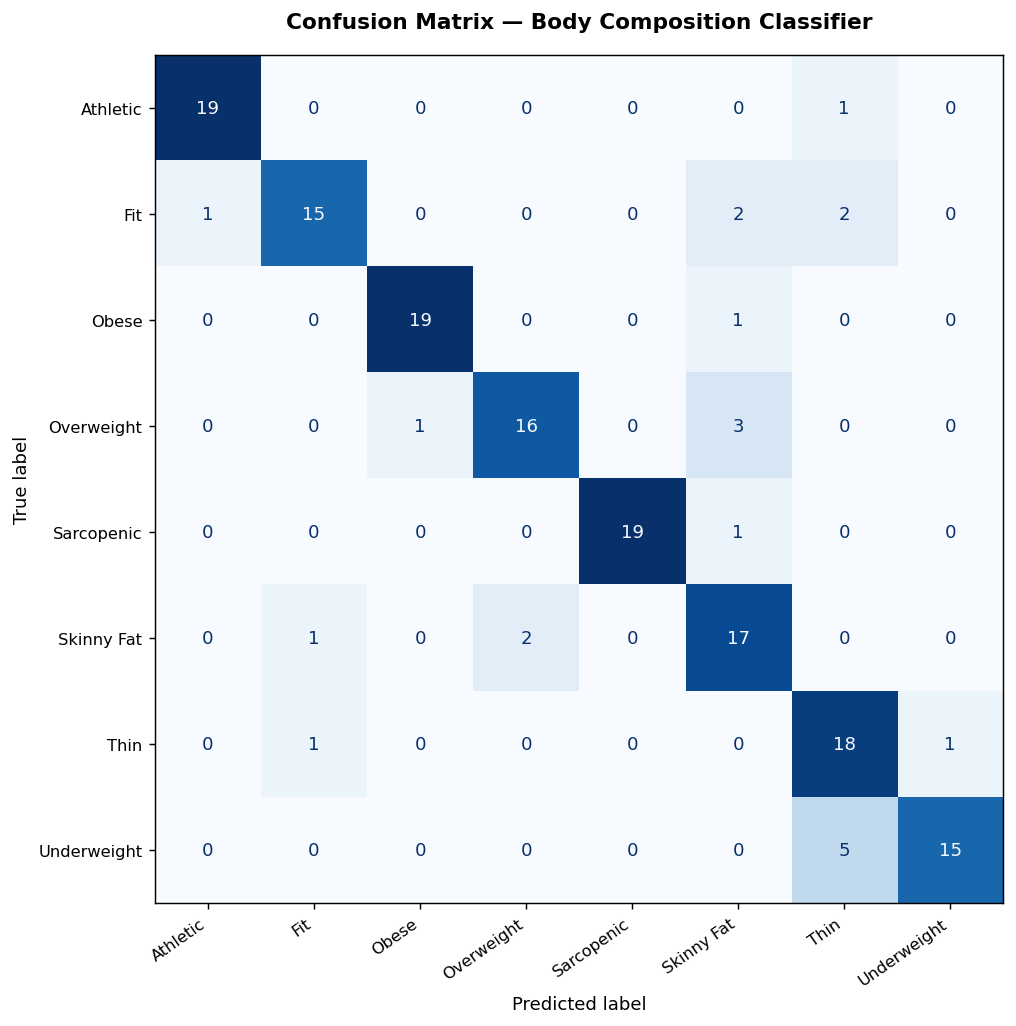

Saved → confusion_matrix.png


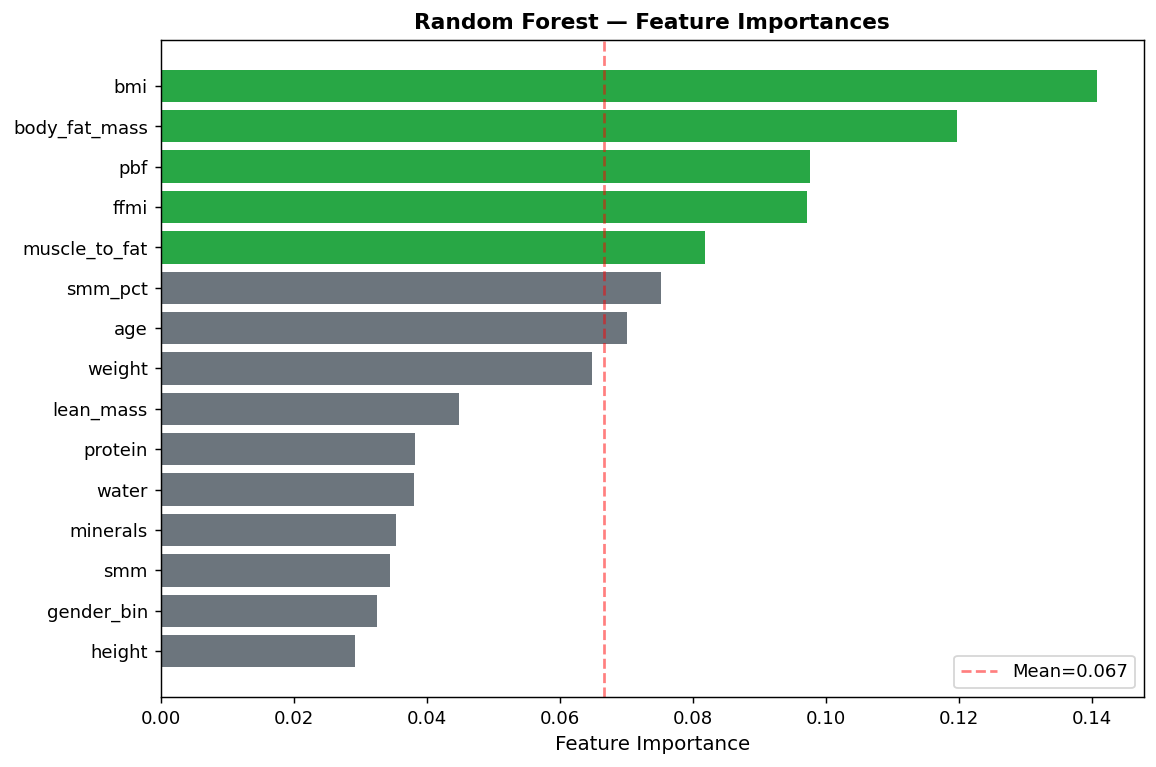

Saved → feature_importance.png


In [63]:
# ── Holdout evaluation on synthetic data ──────────────────────────────────────
syn_fe  = engineer_features(df_syn)
X_s     = syn_fe[FEATURES].fillna(0)
y_s     = syn_fe['true_category']
le_     = artifact['label_encoder']
y_s_enc = le_.transform(y_s)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_s, y_s_enc, test_size=0.2, stratify=y_s_enc, random_state=42)

rf2 = RandomForestClassifier(n_estimators=500, max_features='sqrt',
                              class_weight='balanced', random_state=42, n_jobs=-1)
rf2.fit(X_tr, y_tr)
y_pred = rf2.predict(X_te)

print("📋 Classification Report (20% holdout — synthetic):")
print(classification_report(y_te, y_pred, target_names=le_.classes_))

# ── Confusion matrix ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
cm   = confusion_matrix(y_te, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_.classes_)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Body Composition Classifier', fontweight='bold', pad=15)
plt.xticks(rotation=35, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → confusion_matrix.png")

# ── Feature importance plot ──────────────────────────────────────────────────
fi = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(9, 6))
colors_fi = ['#28a745' if i >= len(fi)-5 else '#6c757d' for i in range(len(fi))]
ax.barh(fi.index, fi.values, color=colors_fi)
ax.set_xlabel('Feature Importance', fontsize=11)
ax.set_title('Random Forest — Feature Importances', fontweight='bold')
ax.axvline(fi.mean(), color='red', linestyle='--', alpha=0.5, label=f'Mean={fi.mean():.3f}')
ax.legend()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → feature_importance.png")


### 🧠 Decision Architecture: Hybrid Logic

The classification process follows a dual-pathway approach, combining medical expertise with machine learning:

| Component | Role | Character |
| :--- | :--- | :--- |
| **Rule Engine** | **Primary Decision** | Always correct, medically grounded, and deterministic. |
| **Random Forest (RF)** | **Secondary Context** | Provides a probability distribution over 8 body classes. |

---

#### ⚖️ Conflict Resolution & Confidence Scoring
To ensure maximum reliability, the final output is calculated based on the agreement between both systems:

*   **✅ If RF Agrees with Rule Engine:**
    *   The classification is confirmed.
    *   **Confidence Boost:** Final score is increased by **+15%** of the RF's confidence level.
*   **⚠️ If RF Disagrees with Rule Engine:**
    *   **Rule Engine Wins:** The deterministic medical label is maintained.
    *   **Context Only:** RF output is recorded for analytical context but does not override the primary label.

> **Outcome:** This strategy ensures the system inherits the "zero-error" property of medical rules while benefiting from the probabilistic insights of AI.

In [67]:
def predict(
    height_cm:    float,
    weight_kg:    float,
    age:          int,
    gender:       str,          # 'male' | 'female'
    pbf:          float,        # % body fat (from InBody/DEXA)
    smm_kg:       float,        # skeletal muscle mass in kg
    body_fat_kg:  float,        # fat mass in kg
    water_kg:     float = None, # total body water (estimated if None)
    protein_kg:   float = None, # body protein     (estimated if None)
    minerals_kg:  float = None, # minerals         (estimated if None)
    model_artifact: dict = None,
) -> dict:
    """
    Hybrid Body Composition Classifier (Rule Engine + Random Forest).

    Parameters
    ----------
    height_cm   : height in centimetres         (valid: 100–220)
    weight_kg   : total body weight kg          (valid: 20–200)
    age         : age in years                  (valid: 5–100)
    gender      : 'male' or 'female'
    pbf         : body fat percentage           (valid: 1–60)
    smm_kg      : skeletal muscle mass kg       (valid: 1–100)
    body_fat_kg : fat mass kg                   (valid: 0.5–120)
    water_kg    : total body water kg           (auto-estimated if None)
    protein_kg  : body protein kg               (auto-estimated if None)
    minerals_kg : minerals kg                   (auto-estimated if None)
    model_artifact : loaded joblib dict         (loaded from file if None)

    Returns
    -------
    dict:
        category         → str   final body composition category
        confidence       → int   0-100
        rule_category    → str   rule engine result
        rf_category      → str   random forest result
        rf_agrees        → bool
        rf_probabilities → dict  {class: probability%}
        reasoning        → str   human-readable explanation
        metrics          → dict  derived physiological metrics
    """
    # ── Input validation ──────────────────────────────────────────────────────
    assert 100 <= height_cm  <= 220,  f"height_cm out of range [100-220]: {height_cm}"
    assert 20  <= weight_kg  <= 200,  f"weight_kg out of range [20-200]: {weight_kg}"
    assert 5   <= age        <= 100,  f"age out of range [5-100]: {age}"
    gender = gender.strip().lower()
    assert gender in ('male','female'), f"gender must be 'male' or 'female', got: '{gender}'"
    assert 1   <= pbf        <= 60,   f"pbf out of range [1-60]: {pbf}"
    assert 1   <= smm_kg     <= 100,  f"smm_kg out of range [1-100]: {smm_kg}"
    assert 0.5 <= body_fat_kg <= 120, f"body_fat_kg out of range [0.5-120]: {body_fat_kg}"

    # ── Load model if needed ──────────────────────────────────────────────────
    if model_artifact is None:
        model_artifact = joblib.load('body_classifier_final.joblib')
    rf_  = model_artifact['model']
    le_  = model_artifact['label_encoder']
    feats= model_artifact['features']
    r    = model_artifact.get('inbody_ratios', {
               'water':WATER_RATIO,'protein':PROTEIN_RATIO,
               'minerals':MINERALS_RATIO,'smm_lean':SMM_LEAN_RATIO})

    # ── Compute derived metrics ───────────────────────────────────────────────
    h_m          = height_cm / 100
    bmi          = round(weight_kg / h_m**2, 2)
    lean_mass    = round(weight_kg * (1 - pbf/100), 2)
    ffmi         = round(lean_mass / h_m**2, 2)
    smm_pct      = round((smm_kg / weight_kg) * 100, 2)
    muscle_to_fat= round(smm_kg / body_fat_kg, 2) if body_fat_kg > 0 else 0
    gender_bin   = 1 if gender == 'male' else 0

    # Auto-estimate InBody water/protein/minerals if not provided
    if water_kg    is None: water_kg    = round(lean_mass * r['water'],    1)
    if protein_kg  is None: protein_kg  = round(lean_mass * r['protein'],  2)
    if minerals_kg is None: minerals_kg = round(lean_mass * r['minerals'], 2)

    # ── Rule engine (primary) ─────────────────────────────────────────────────
    row = pd.Series({
        'gender':gender,'bmi':bmi,'pbf':pbf,'ffmi':ffmi,'smm_pct':smm_pct,
        'height':height_cm,'age':age,'gender_bin':gender_bin,
        'weight':weight_kg,'smm':smm_kg,'body_fat_mass':body_fat_kg,
        'water':water_kg,'protein':protein_kg,'minerals':minerals_kg,
        'lean_mass':lean_mass,'muscle_to_fat':muscle_to_fat,
    })
    rule_cat, rule_conf, reasoning = rule_classify(row)

    # ── RF prediction (secondary) ─────────────────────────────────────────────
    X_in    = pd.DataFrame([row[feats].values], columns=feats).fillna(0)
    rf_proba= rf_.predict_proba(X_in)[0]
    rf_cat  = le_.inverse_transform([rf_proba.argmax()])[0]
    rf_conf = int(rf_proba.max() * 100)

    # ── Hybrid decision ───────────────────────────────────────────────────────
    agrees     = (rf_cat == rule_cat)
    final_cat  = rule_cat
    final_conf = rule_conf if not agrees else min(100, rule_conf + int(rf_conf * 0.15))

    return {
        'category':         final_cat,
        'confidence':       final_conf,
        'rule_category':    rule_cat,
        'rf_category':      rf_cat,
        'rf_agrees':        agrees,
        'rf_probabilities': {le_.classes_[i]: round(float(p)*100, 1)
                             for i, p in enumerate(rf_proba)},
        'reasoning':        reasoning,
        'metrics': {
            'BMI':           bmi,
            'Body_Fat_pct':  pbf,
            'FFMI':          ffmi,
            'SMM_pct':       smm_pct,
            'Lean_Mass_kg':  lean_mass,
            'Muscle_to_Fat': muscle_to_fat,
        }
    }

# Load saved model
artifact = joblib.load('body_classifier_final.joblib')
print(f"✅ predict() ready | CV={artifact['cv_accuracy']*100:.1f}% | classes: {artifact['classes']}")


✅ predict() ready | CV=85.6% | classes: ['Athletic', 'Fit', 'Obese', 'Overweight', 'Sarcopenic', 'Skinny Fat', 'Thin', 'Underweight']


## Test All 8 Categories

In [70]:
def pretty_print(res: dict):
    cat   = res['category']
    agree = f"✅ RF agrees ({res['rf_category']})" if res['rf_agrees'] else f"⚠️  RF says: {res['rf_category']}"
    top3  = dict(sorted(res['rf_probabilities'].items(), key=lambda x:-x[1])[:3])
    m     = res['metrics']
    print(f"""
╔══════════════════════════════════════════════════╗
  {EMOJI.get(cat,''):<3} {cat:<15}  Confidence: {res['confidence']}%
  {agree}
  Reason : {res['reasoning']}
  BMI={m['BMI']}  PBF={m['Body_Fat_pct']}%  FFMI={m['FFMI']}  SMM%={m['SMM_pct']}%
  RF top-3: {top3}
╚══════════════════════════════════════════════════╝""")

TESTS = [
    ('🏆 Athletic Male',    dict(height_cm=181,weight_kg=82,age=24,gender='male',   pbf=9,  smm_kg=40,body_fat_kg=7.4)),
    ('💪 Fit Female',       dict(height_cm=165,weight_kg=60,age=28,gender='female', pbf=24, smm_kg=21,body_fat_kg=14.4)),
    ('🔴 Obese Male',       dict(height_cm=172,weight_kg=105,age=42,gender='male',  pbf=37, smm_kg=34,body_fat_kg=38.9)),
    ('⚠️ Overweight Female',dict(height_cm=162,weight_kg=78,age=38,gender='female', pbf=36, smm_kg=23,body_fat_kg=28.1)),
    ('📉 Underweight Male', dict(height_cm=175,weight_kg=52,age=19,gender='male',   pbf=8,  smm_kg=22,body_fat_kg=4.2)),
    ('🦴 Thin Female',      dict(height_cm=163,weight_kg=46,age=22,gender='female', pbf=20, smm_kg=16,body_fat_kg=9.2)),
    ('👻 Skinny Fat Male',  dict(height_cm=175,weight_kg=72,age=32,gender='male',   pbf=26, smm_kg=27,body_fat_kg=18.7)),
    ('🧓 Sarcopenic Female',dict(height_cm=158,weight_kg=60,age=58,gender='female', pbf=36, smm_kg=15,body_fat_kg=21.6)),
]

for label, params in TESTS:
    print(f"\n  ▶ TEST: {label}")
    res = predict(**params, model_artifact=artifact)
    pretty_print(res)



  ▶ TEST: 🏆 Athletic Male

╔══════════════════════════════════════════════════╗
  🏆   Athletic         Confidence: 100%
  ✅ RF agrees (Athletic)
  Reason : PBF=9.0%  |  FFMI=22.8  |  SMM%=48.8%
  BMI=25.03  PBF=9%  FFMI=22.78  SMM%=48.78%
  RF top-3: {'Athletic': 100.0, 'Fit': 0.0, 'Obese': 0.0}
╚══════════════════════════════════════════════════╝

  ▶ TEST: 💪 Fit Female

╔══════════════════════════════════════════════════╗
  💪   Fit              Confidence: 100%
  ✅ RF agrees (Fit)
  Reason : FFMI=16.8  |  PBF=24.0%  |  SMM%=35.0%
  BMI=22.04  PBF=24%  FFMI=16.75  SMM%=35.0%
  RF top-3: {'Fit': 57.6, 'Skinny Fat': 19.4, 'Athletic': 13.4}
╚══════════════════════════════════════════════════╝

  ▶ TEST: 🔴 Obese Male

╔══════════════════════════════════════════════════╗
  🔴   Obese            Confidence: 95%
  ✅ RF agrees (Obese)
  Reason : BMI=35.5≥30  &  PBF=37.0%>30%
  BMI=35.49  PBF=37%  FFMI=22.36  SMM%=32.38%
  RF top-3: {'Obese': 99.8, 'Fit': 0.2, 'Athletic': 0.0}
╚═══════════════

 ## Batch Classify Real Data & Export to Excel

In [79]:

def batch_classify(df_input: pd.DataFrame) -> pd.DataFrame:
    """Classify all rows. Returns df with category / confidence / reasoning + RF probs."""
    df  = engineer_features(df_input.copy())
    res = df.apply(lambda r: rule_classify(r), axis=1, result_type='expand')
    res.columns = ['category','confidence','reasoning']
    df['category']   = res['category']
    df['confidence'] = res['confidence']
    df['reasoning']  = res['reasoning']
    # RF probabilities
    X     = df[FEATURES].fillna(0)
    proba = artifact['model'].predict_proba(X)
    le_   = artifact['label_encoder']
    for i, cls in enumerate(le_.classes_):
        df[f'prob_{cls}'] = (proba[:,i]*100).round(1)
    return df

# ── Classify real data ────────────────────────────────────────────────────────
df_real = pd.read_excel(r"Downloads/Workbook1.xlsx")
df_classified = batch_classify(df_real)

print(f"✅ Classified {len(df_classified)} real records")
print("\nDistribution on real data:")
vc2 = df_classified['category'].value_counts()
for cat, n in vc2.items():
    bar = '█' * (n//5)
    print(f"  {EMOJI.get(cat,''):<2} {cat:<15} {n:>3}  {bar}")

# ── Export styled Excel ───────────────────────────────────────────────────────
EXCEL_COLORS = {
    'Athletic':'D4EDDA','Fit':'CCE5FF','Overweight':'FFF3CD','Obese':'F8D7DA',
    'Underweight':'FFEEBA','Thin':'E2E3E5','Skinny Fat':'F5C6CB','Sarcopenic':'D6D8D9'
}
export_cols = ['gender','age','height','weight','bmi','pbf','smm','body_fat_mass',
               'lean_mass','ffmi','smm_pct','muscle_to_fat','category','confidence','reasoning']
out = df_classified[export_cols].round(2).copy()
out.columns = ['Gender','Age','Height(cm)','Weight(kg)','BMI','Body Fat%',
               'SMM(kg)','Fat Mass(kg)','Lean Mass(kg)','FFMI','SMM%',
               'Muscle/Fat','Category','Confidence%','Reasoning']

path = 'body_classification_results.xlsx'
out.to_excel(path, index=False, sheet_name='Classifications')

wb = load_workbook(path)
ws = wb['Classifications']
hfill = PatternFill('solid', fgColor='1F4E79')
hfont = Font(bold=True, color='FFFFFF', name='Calibri', size=10)
for cell in ws[1]:
    cell.fill=hfill; cell.font=hfont
    cell.alignment=Alignment(horizontal='center',vertical='center',wrap_text=True)
cat_idx = [c.value for c in ws[1]].index('Category')+1
for row in ws.iter_rows(min_row=2, max_row=ws.max_row):
    v = row[cat_idx-1].value
    if v in EXCEL_COLORS:
        fill = PatternFill('solid', fgColor=EXCEL_COLORS[v])
        for cell in row:
            cell.fill=fill; cell.alignment=Alignment(horizontal='center',vertical='center')
        row[cat_idx-1].font = Font(bold=True, name='Calibri')
for col in ws.columns:
    w = max((len(str(c.value or '')) for c in col), default=8)
    ws.column_dimensions[get_column_letter(col[0].column)].width = min(w+3, 35)
ws.freeze_panes='A2'; ws.row_dimensions[1].height=28
# Summary sheet
ws2 = wb.create_sheet('Summary')
hdrs = ['Category','Emoji','Count','% of Total','Avg BMI','Avg PBF%','Avg FFMI','Avg SMM%','Avg Confidence']
for i,h in enumerate(hdrs,1): ws2.cell(1,i,h)
sg = df_classified.groupby('category').agg(
    count=('category','count'), bmi=('bmi','mean'), pbf=('pbf','mean'),
    ffmi=('ffmi','mean'), smm=('smm_pct','mean'), conf=('confidence','mean')).round(1)
for i,(cat,r) in enumerate(sg.iterrows(),2):
    vals=[cat, EMOJI.get(cat,''), r['count'], f"{r['count']/len(df_classified)*100:.1f}%",
          r['bmi'], r['pbf'], r['ffmi'], r['smm'], r['conf']]
    for j,v in enumerate(vals,1):
        ws2.cell(i,j,v)
    fill=PatternFill('solid',fgColor=EXCEL_COLORS.get(cat,'FFFFFF'))
    for j in range(1,len(vals)+1): ws2.cell(i,j).fill=fill
for cell in ws2[1]:
    cell.fill=hfill; cell.font=hfont; cell.alignment=Alignment(horizontal='center')
for col in ws2.columns:
    ws2.column_dimensions[get_column_letter(col[0].column)].width=16
wb.save(path)
print(f"\n💾 Saved → {path}  [sheets: Classifications · Summary]")


✅ Classified 378 real records

Distribution on real data:
  💪  Fit             247  █████████████████████████████████████████████████
  🏆  Athletic         71  ██████████████
  🔴  Obese            22  ████
  👻  Skinny Fat       16  ███
  🦴  Thin             11  ██
  ⚠️ Overweight       11  ██

💾 Saved → body_classification_results.xlsx  [sheets: Classifications · Summary]
